# 03 · OE4 — Conglomerados (análisis de conglomerados)
**Iván Ramiro Pinzón Pinto** — Ciencia de Datos, Universidad Externado de Colombia · Tutora: Yessica Velásquez

*Implementa §3.x (conglomerados, robustez y pruebas estadísticas).* **Requiere `02_OE2-OE3_ICP_IPD`.**


In [2]:
import pandas as pd
import numpy as np
import json
import re
import os
import warnings
from glob import glob
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, silhouette_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from itertools import combinations
from matplotlib.patches import Patch
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.inspection import permutation_importance
from sklearn.metrics import adjusted_rand_score, silhouette_samples
import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Librerías cargadas correctamente.")

c:\Users\ivanr\.conda\envs\pyfhel\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas correctamente.


### Carga de insumos
Se recompone `habil_normal` (subconjunto de meses normales y días hábiles) a partir del panel, porque las celdas de conglomerados lo usan.


In [3]:
import os
import pandas as pd

RAIZ = os.getcwd()
if os.path.basename(RAIZ) == 'notebooks':
    RAIZ = os.path.dirname(RAIZ)
DATA_INT = os.path.join(RAIZ, 'data', 'intermedia')
OUT_FIG  = os.path.join(RAIZ, 'outputs', 'figuras')
OUT_TAB  = os.path.join(RAIZ, 'outputs', 'tablas')
os.makedirs(OUT_FIG, exist_ok=True); os.makedirs(OUT_TAB, exist_ok=True)

ipd_df = pd.read_parquet(os.path.join(DATA_INT, 'panel_icp_ipd.parquet'))
meses_normales = [2, 3, 4, 5, 8, 9, 10, 11]
habil_normal = ipd_df[(ipd_df['mes'].isin(meses_normales)) & (ipd_df['dia_semana'] < 5) & (ipd_df['es_festivo'] == 0)]
print(f'Panel: {len(ipd_df):,} filas | habil_normal: {len(habil_normal):,} filas')

Panel: 7,957,878 filas | habil_normal: 3,548,489 filas


## 8. Clasificación de estaciones (análisis de conglomerados)

Se agrupan las estaciones según su perfil temporal de presión de demanda usando K-Means con estandarización z-score.

In [4]:
# =============================================
# PERFILES PARA CLUSTERING
# =============================================

perfiles = habil_normal.groupby(['estacion', 'hora'])['ipd'].mean().reset_index()
perfiles_pivot = perfiles.pivot(index='estacion', columns='hora', values='ipd').fillna(0)

perfiles_pivot['ipd_mean'] = perfiles_pivot.mean(axis=1)
perfiles_pivot['ipd_std'] = perfiles_pivot.iloc[:, :-1].std(axis=1)
perfiles_pivot['ipd_max'] = perfiles_pivot.iloc[:, :-2].max(axis=1)

# Convertir columnas a string
perfiles_pivot.columns = perfiles_pivot.columns.astype(str)
features_cols = perfiles_pivot.columns.tolist()

# Estandarización z-score
scaler = StandardScaler()
X_cluster = scaler.fit_transform(perfiles_pivot[features_cols])

print(f"Features para clustering: {X_cluster.shape[1]} variables, {X_cluster.shape[0]} estaciones")

Features para clustering: 27 variables, 144 estaciones


K=2: inercia=2514, silhouette=0.488
K=3: inercia=1844, silhouette=0.518
K=4: inercia=1386, silhouette=0.531
K=5: inercia=1125, silhouette=0.368
K=6: inercia=1001, silhouette=0.374
K=7: inercia=868, silhouette=0.309
K=8: inercia=783, silhouette=0.304


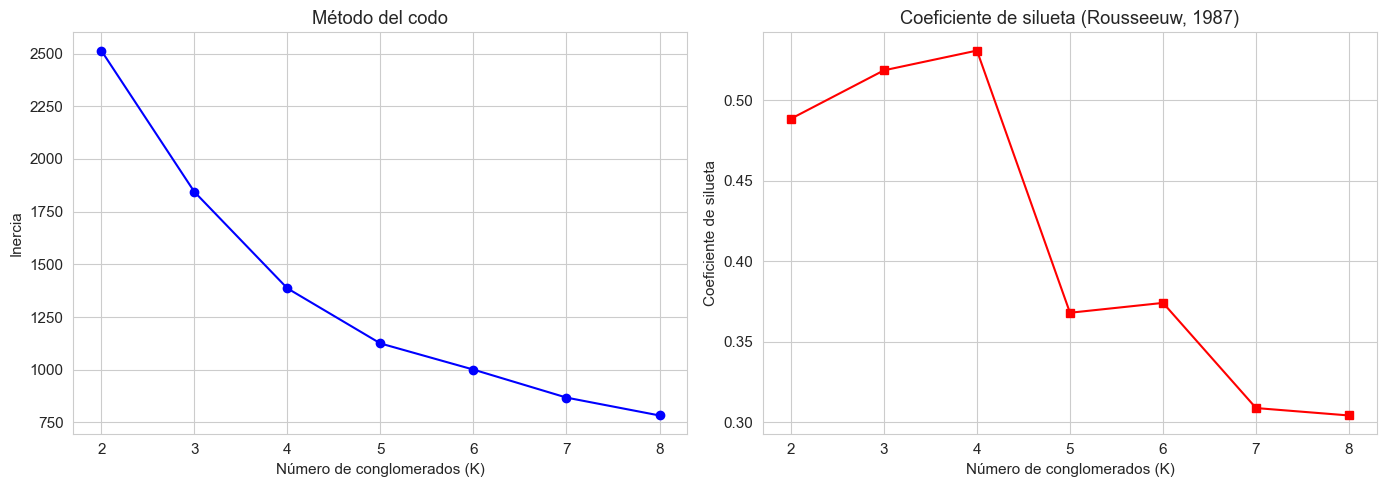


K óptimo por silueta: 4


In [5]:
# =============================================
# SELECCIÓN DE K (MÉTODO DEL CODO + COEFICIENTE DE SILUETA)
# =============================================

inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: inercia={km.inertia_:.0f}, silhouette={sil:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Número de conglomerados (K)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del codo')

ax2.plot(K_range, silhouette_scores, 'rs-')
ax2.set_xlabel('Número de conglomerados (K)')
ax2.set_ylabel('Coeficiente de silueta')
ax2.set_title('Coeficiente de silueta (Rousseeuw, 1987)')

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig3_elbow_silhouette.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nK óptimo por silueta: {list(K_range)[silhouette_scores.index(max(silhouette_scores))]}")

In [6]:
# =============================================
# K-MEANS — K=4
# =============================================

K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
perfiles_pivot['cluster'] = km.fit_predict(X_cluster)

print("Resumen por conglomerado:\n")
for c in range(K):
    est_cluster = perfiles_pivot[perfiles_pivot['cluster'] == c]
    print(f"Conglomerado {c}: {len(est_cluster)} estaciones")
    print(f"  IPD promedio: {est_cluster['ipd_mean'].mean():.3f}")
    print(f"  IPD máximo:   {est_cluster['ipd_max'].mean():.3f}")
    print(f"  Estaciones:   {', '.join(est_cluster.index[:5])}")
    if len(est_cluster) > 5:
        print(f"                ... y {len(est_cluster)-5} más")
    print()

cluster_df = perfiles_pivot[['cluster', 'ipd_mean', 'ipd_max']].reset_index()

Resumen por conglomerado:

Conglomerado 0: 29 estaciones
  IPD promedio: 0.252
  IPD máximo:   0.948
  Estaciones:   AV. Chile, AV. Jiménez, Calle 100 - Marketmedios, Calle 106, Calle 45 - American School Way
                ... y 24 más

Conglomerado 1: 100 estaciones
  IPD promedio: 0.088
  IPD máximo:   0.363
  Estaciones:   21 Ángeles, 7 de agosto, AV. 39, AV. 68, AV. Américas - AV. Boyacá
                ... y 95 más

Conglomerado 2: 2 estaciones
  IPD promedio: 0.184
  IPD máximo:   0.743
  Estaciones:   Campín - UAN, Movistar Arena

Conglomerado 3: 13 estaciones
  IPD promedio: 0.254
  IPD máximo:   1.141
  Estaciones:   Banderas, Bosa, Portal 20 de Julio, Portal 80, Portal Américas
                ... y 8 más



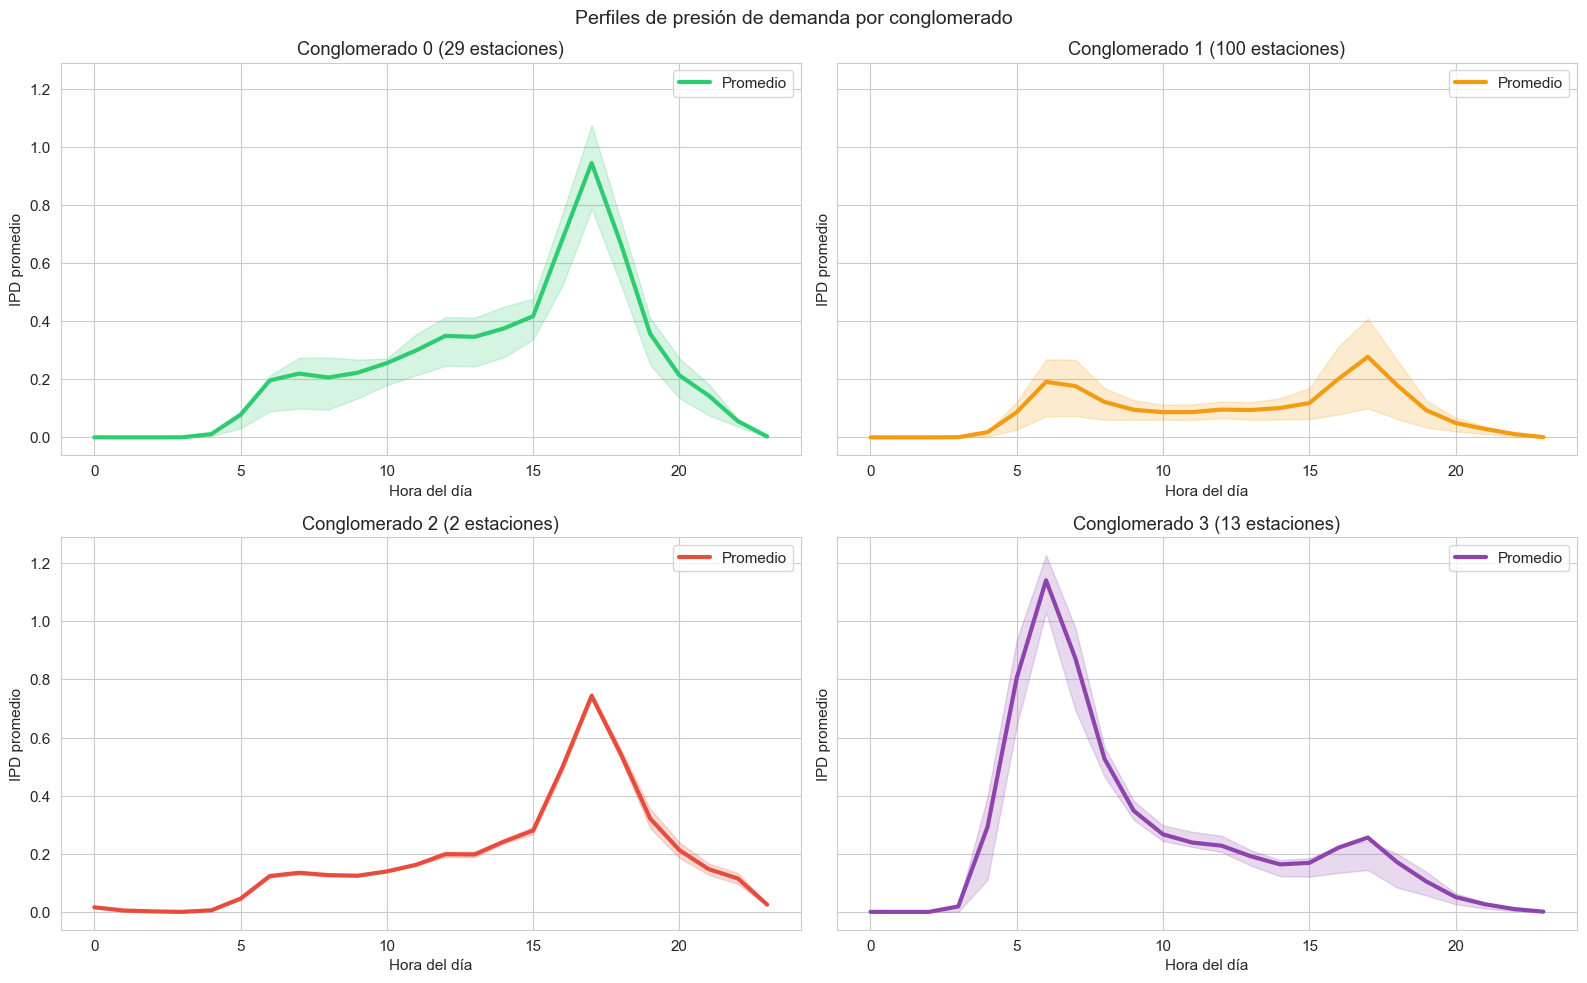

In [7]:
# =============================================
# PERFILES POR CONGLOMERADO
# =============================================

hora_cols = [c for c in perfiles_pivot.columns
             if c not in ['cluster', 'ipd_mean', 'ipd_std', 'ipd_max']
             and c.isdigit()]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

for c in range(K):
    ax = axes[c // 2][c % 2]
    cluster_data = perfiles_pivot[perfiles_pivot['cluster'] == c][hora_cols]
    mean_profile = cluster_data.mean()
    x = [int(h) for h in mean_profile.index]
    ax.plot(x, mean_profile.values, color=colors[c], linewidth=3, label='Promedio')
    ax.fill_between(x,
                    cluster_data.quantile(0.25).values,
                    cluster_data.quantile(0.75).values,
                    alpha=0.2, color=colors[c])
    ax.set_title(f'Conglomerado {c} ({len(cluster_data)} estaciones)')
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('IPD promedio')
    ax.legend()

plt.suptitle('Perfiles de presión de demanda por conglomerado', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig4_perfiles_conglomerados.png'), dpi=150, bbox_inches='tight')
plt.show()

Silueta K=4 (solo picos): 0.407
Silueta K=4 (todo el día): 0.531

CLUSTERING SOLO HORAS PICO (6-9 + 17-20)

Cluster 0: 73 estaciones
  IPD medio: 0.129
  IPD máx:   0.287
  Estaciones: Country Sur, Normandía, Terminal, Alcalá - Col. S. Tomás Dominicos, Biblioteca Tintal, León XIII, Restrepo, Alquería
              ... y 65 más

Cluster 1: 38 estaciones
  IPD medio: 0.223
  IPD máx:   0.628
  Estaciones: Distrito Grafiti, Suba - Calle 100, De la Sabana, AV. Chile, Paloquemao, Calle 106, Las Nieves, Movistar Arena
              ... y 30 más

Cluster 2: 18 estaciones
  IPD medio: 0.423
  IPD máx:   1.062
  Estaciones: Pradera - Plaza Central, Calle 100 - Marketmedios, Suba - Calle 95, KR 53, KR 43 - COMAPAN, Museo del Oro, Calle 63, San Victorino
              ... y 10 más

Cluster 3: 15 estaciones
  IPD medio: 0.434
  IPD máx:   1.079
  Estaciones: Portal Eldorado - C.C. NUESTRO BOGOTÁ, Portal 80, San Mateo, Portal Tunal, Comuneros, Portal Suba, Portal Américas, Portal 20 de Julio
      

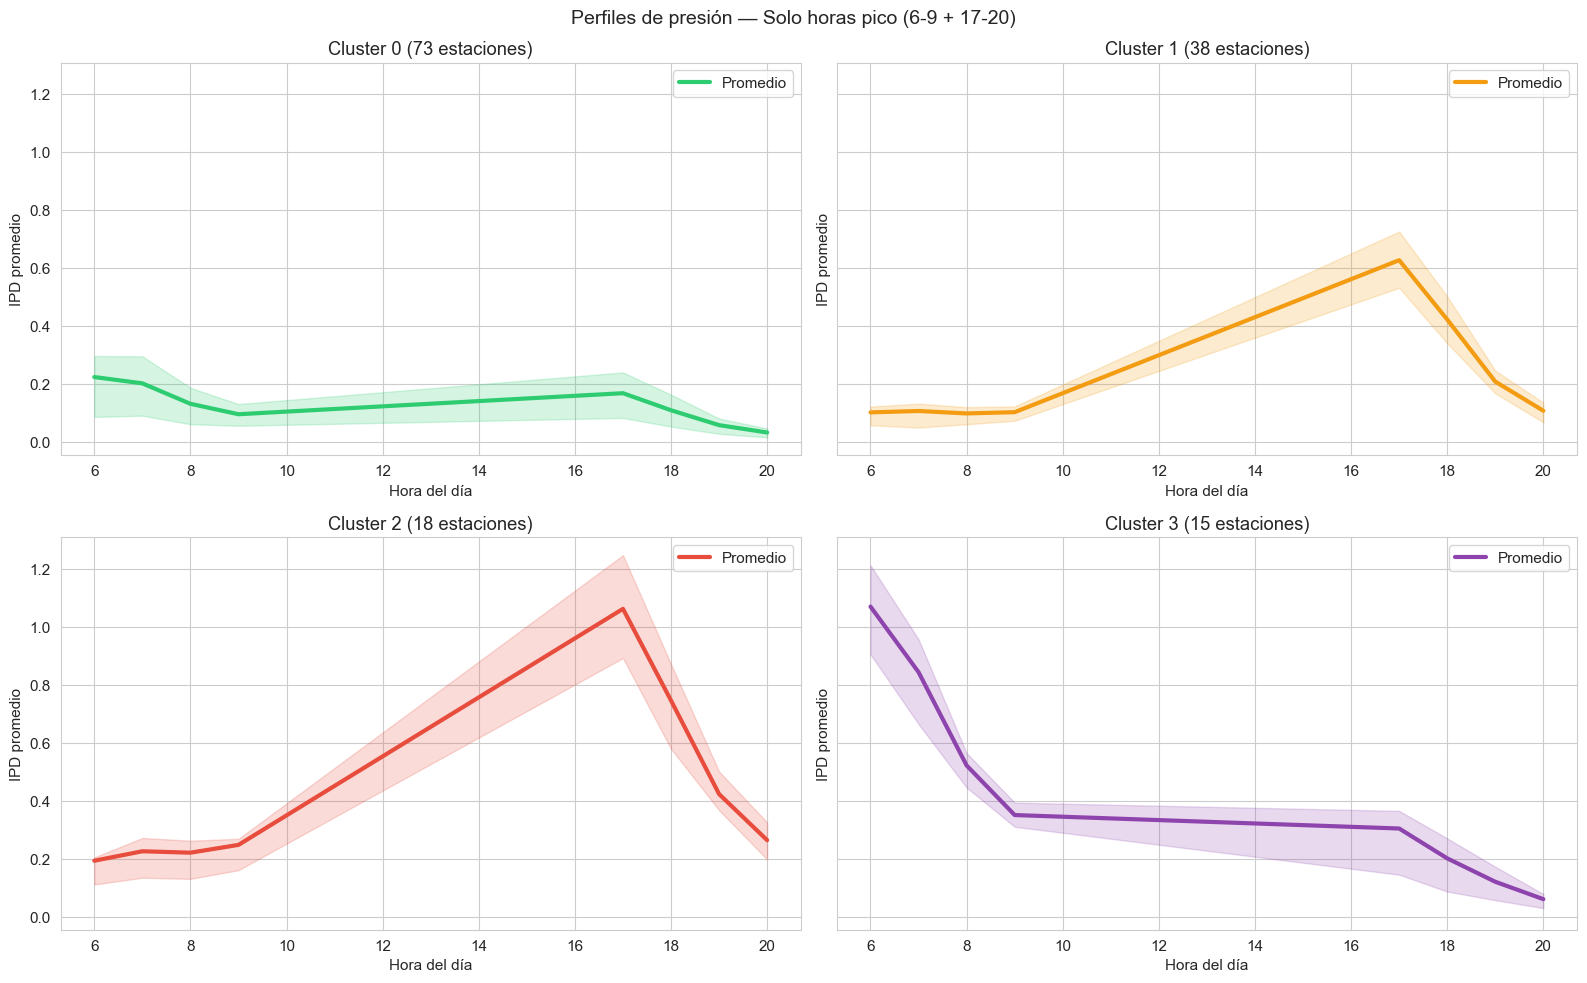

In [8]:
# =============================================
# ANÁLISIS COMPLEMENTARIO: CLUSTERING SOLO HORAS PICO
# =============================================

# Filtrar solo picos AM (6-9) y PM (17-20)
pico = habil_normal[
    (habil_normal['hora'].between(6, 9)) | 
    (habil_normal['hora'].between(17, 20))
]

perfiles_pico = pico.groupby(['estacion', 'hora'])['ipd'].mean().reset_index()
pivot_pico = perfiles_pico.pivot(index='estacion', columns='hora', values='ipd').fillna(0)
pivot_pico['ipd_mean'] = pivot_pico.mean(axis=1)
pivot_pico['ipd_max'] = pivot_pico.max(axis=1)
pivot_pico.columns = pivot_pico.columns.astype(str)

X_pico = StandardScaler().fit_transform(pivot_pico)

# K=4 con solo horas pico
km_pico = KMeans(n_clusters=4, random_state=42, n_init=10)
pivot_pico['cluster_pico'] = km_pico.fit_predict(X_pico)
sil_pico = silhouette_score(X_pico, pivot_pico['cluster_pico'])

print(f"Silueta K=4 (solo picos): {sil_pico:.3f}")
print(f"Silueta K=4 (todo el día): {silhouette_scores[2]:.3f}")  # index 2 = K=4

# Ordenar clusters por IPD medio
cluster_order = pivot_pico.groupby('cluster_pico')['ipd_mean'].mean().sort_values()
label_map = {old: new for new, old in enumerate(cluster_order.index)}
pivot_pico['cluster_pico_ord'] = pivot_pico['cluster_pico'].map(label_map)

print(f"\n{'='*60}")
print("CLUSTERING SOLO HORAS PICO (6-9 + 17-20)")
print(f"{'='*60}")

for c in range(4):
    sub = pivot_pico[pivot_pico['cluster_pico_ord'] == c].sort_values('ipd_mean', ascending=False)
    print(f"\nCluster {c}: {len(sub)} estaciones")
    print(f"  IPD medio: {sub['ipd_mean'].mean():.3f}")
    print(f"  IPD máx:   {sub['ipd_max'].mean():.3f}")
    print(f"  Estaciones: {', '.join(sub.index[:8])}")
    if len(sub) > 8:
        print(f"              ... y {len(sub)-8} más")

# ¿Dónde queda Universidades, Calle 100, Terminal?
print(f"\n{'='*60}")
print("ESTACIONES CLAVE — COMPARACIÓN")
print(f"{'='*60}")
print(f"{'Estación':45s} {'C. día':>7s} {'C. pico':>8s} {'IPD pico':>9s}")
print("-" * 72)

cluster_dia = perfiles_pivot['cluster'].to_dict()

for est in ['Universidades - CityU', 'Calle 100 - Marketmedios', 'Terminal',
            'Pradera - Plaza Central', 'Portal Américas', 'Portal 80',
            'Calle 76', 'Calle 72', 'AV. Jiménez', 'San Mateo',
            'Portal Suba', 'Toberín - Foundever']:
    if est in pivot_pico.index and est in cluster_dia:
        c_dia = int(cluster_dia[est])
        c_pico = int(pivot_pico.loc[est, 'cluster_pico_ord'])
        ipd_m = pivot_pico.loc[est, 'ipd_mean']
        cambio = "  <<<" if c_pico != c_dia else ""
        print(f"{est:45s} {c_dia:>7d} {c_pico:>8d} {ipd_m:>9.3f}{cambio}")

# Perfiles visuales
hora_cols_pico = [c for c in pivot_pico.columns 
                  if c not in ['cluster_pico', 'cluster_pico_ord', 'ipd_mean', 'ipd_max', 'ipd_std']
                  and c.isdigit()]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

for c in range(4):
    ax = axes[c // 2][c % 2]
    cluster_data = pivot_pico[pivot_pico['cluster_pico_ord'] == c][hora_cols_pico]
    mean_profile = cluster_data.mean()
    x = [int(h) for h in mean_profile.index]
    ax.plot(x, mean_profile.values, color=colors[c], linewidth=3, label='Promedio')
    ax.fill_between(x,
                    cluster_data.quantile(0.25).values,
                    cluster_data.quantile(0.75).values,
                    alpha=0.2, color=colors[c])
    ax.set_title(f'Cluster {c} ({len(cluster_data)} estaciones)')
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('IPD promedio')
    ax.legend()

plt.suptitle('Perfiles de presión — Solo horas pico (6-9 + 17-20)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_perfiles_solo_picos.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# =============================================
# ASIGNACION DEL CONGLOMERADO AL DATASET COMPLETO
# =============================================
# Se mapea la etiqueta de conglomerado de cada estacion (cluster_df) sobre
# el dataset completo ipd_df, para los analisis posteriores por conglomerado
# (boxplot, pruebas estadisticas y modelo).

cluster_map = cluster_df.set_index('estacion')['cluster'].to_dict()
ipd_df['cluster'] = ipd_df['estacion'].map(cluster_map)
print(f"Conglomerado asignado a {ipd_df['cluster'].notna().sum():,} registros "
      f"({int(ipd_df['cluster'].nunique())} conglomerados).")


Conglomerado asignado a 7,957,878 registros (4 conglomerados).


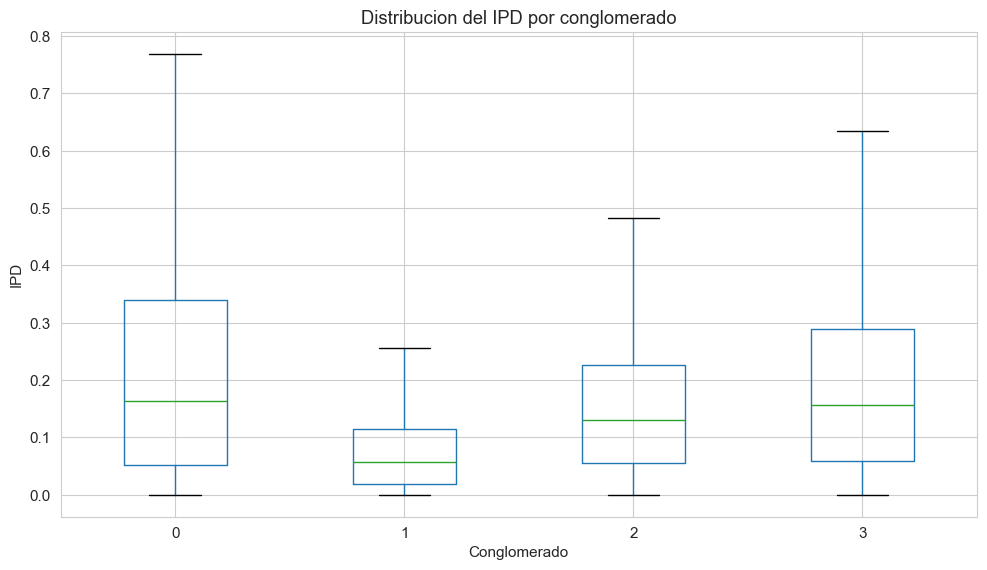

Estadisticas descriptivas del IPD por conglomerado:
             count   mean    std  min    25%    50%    75%    max
cluster                                                          
0        1527411.0  0.244  0.268  0.0  0.052  0.163  0.339  2.993
1        5527807.0  0.086  0.104  0.0  0.019  0.056  0.114  1.931
2         119931.0  0.180  0.199  0.0  0.056  0.130  0.226  3.231
3         782729.0  0.243  0.288  0.0  0.059  0.156  0.289  3.055


In [10]:
# =============================================
# DISTRIBUCION DEL IPD POR CONGLOMERADO
# =============================================

ipd_df_cl = ipd_df[ipd_df['cluster'].notna()].copy()
ipd_df_cl['cluster'] = ipd_df_cl['cluster'].astype(int)

fig, ax = plt.subplots(figsize=(10, 6))
ipd_df_cl.boxplot(column='ipd', by='cluster', ax=ax, showfliers=False)
ax.set_title('Distribucion del IPD por conglomerado')
ax.set_xlabel('Conglomerado')
ax.set_ylabel('IPD')
plt.suptitle('')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_ipd_por_conglomerado.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Estadisticas descriptivas del IPD por conglomerado:")
print(ipd_df_cl.groupby('cluster')['ipd'].describe().round(3).to_string())


### Validación de los conglomerados

Coeficiente de silueta por estación, estabilidad ante múltiples inicializaciones y dendrograma como contraste con el agrupamiento jerárquico.

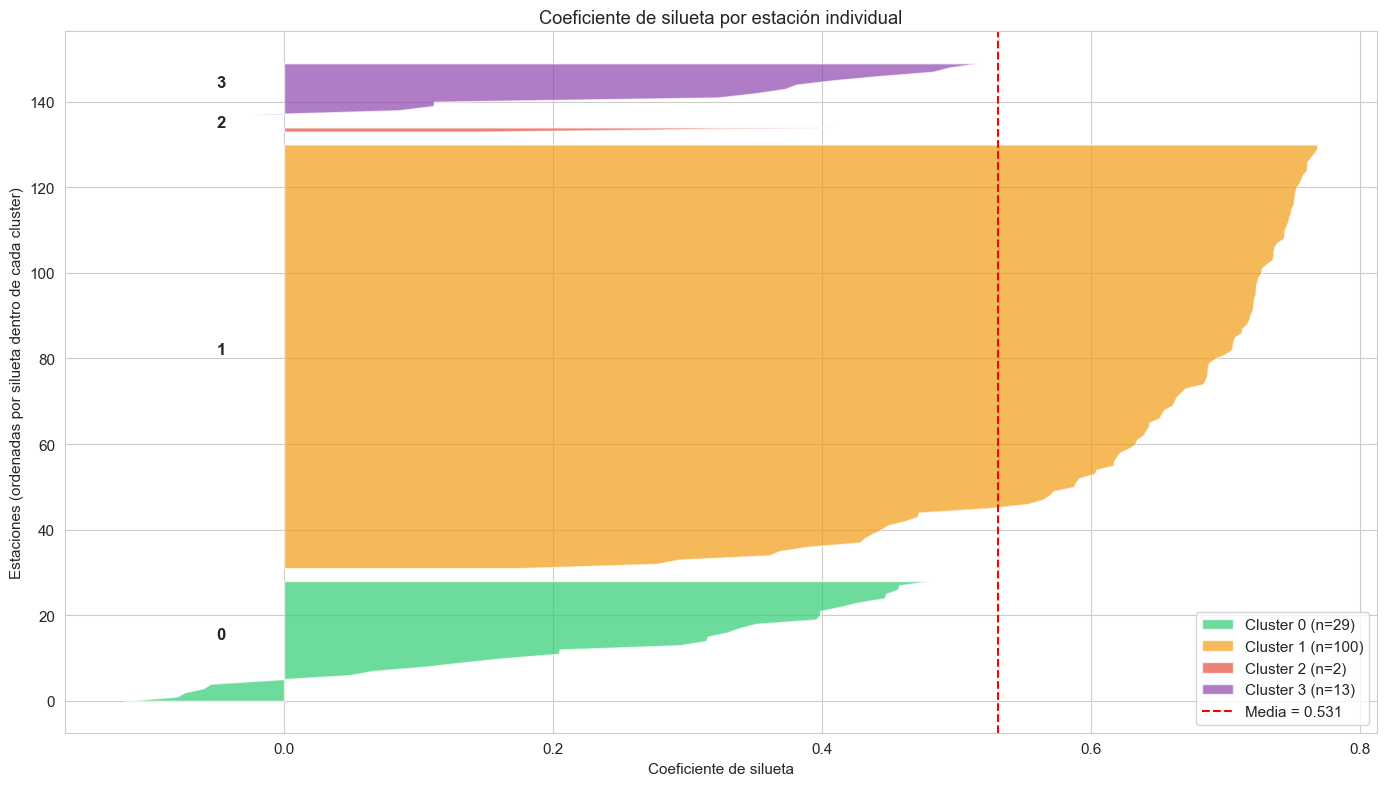

Estaciones con silueta negativa: 7
  AV. Chile                                 cluster=0  silueta=-0.080
  AV. Jiménez                               cluster=0  silueta=-0.005
  Calle 106                                 cluster=0  silueta=-0.119
  Calle 72                                  cluster=0  silueta=-0.060
  Distrito Grafiti                          cluster=0  silueta=-0.055
  Portal Norte                              cluster=3  silueta=-0.025
  Suba - Calle 100                          cluster=0  silueta=-0.074


In [11]:
# =============================================
# SILUETA POR ESTACIÓN INDIVIDUAL
# =============================================

from sklearn.metrics import silhouette_samples

sil_samples = silhouette_samples(X_cluster, perfiles_pivot['cluster'].values)
perfiles_pivot['silhouette'] = sil_samples

fig, ax = plt.subplots(figsize=(14, 8))
y_lower = 0
colors_cl = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

for c in range(K):
    cluster_sil = np.sort(sil_samples[perfiles_pivot['cluster'].values == c])
    size = len(cluster_sil)
    y_upper = y_lower + size
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                      facecolor=colors_cl[c], alpha=0.7, label=f'Cluster {c} (n={size})')
    ax.text(-0.05, y_lower + 0.5 * size, str(c), fontweight='bold', fontsize=12)
    y_lower = y_upper + 2

ax.axvline(x=sil_samples.mean(), color='red', linestyle='--',
           label=f'Media = {sil_samples.mean():.3f}')
ax.set_xlabel('Coeficiente de silueta')
ax.set_ylabel('Estaciones (ordenadas por silueta dentro de cada cluster)')
ax.set_title('Coeficiente de silueta por estación individual')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_silueta_individual.png'), dpi=150, bbox_inches='tight')
plt.show()

# Estaciones con silueta negativa (mal asignadas)
mal_asignadas = perfiles_pivot[perfiles_pivot['silhouette'] < 0]
print(f"Estaciones con silueta negativa: {len(mal_asignadas)}")
for est, row in mal_asignadas.iterrows():
    print(f"  {est:40s}  cluster={int(row['cluster'])}  silueta={row['silhouette']:.3f}")

=== ESTABILIDAD DE CLUSTERS (20 inicializaciones) ===
  ARI medio entre corridas: 0.972
  ARI mínimo:               0.720
  ARI máximo:               1.000
  DE:                        0.084
  -> Clusters ALTAMENTE ESTABLES.


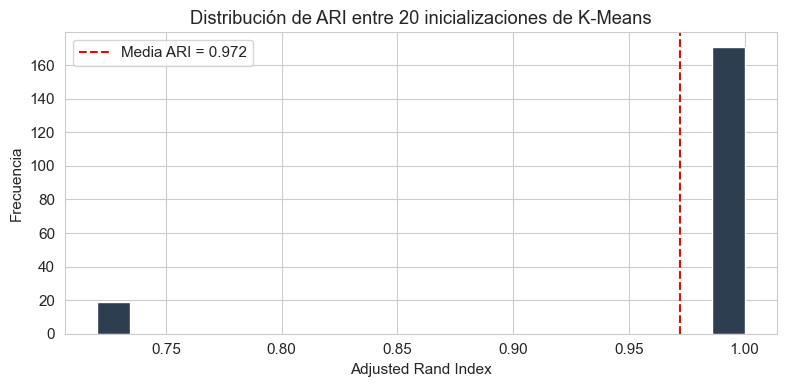

In [12]:
# =============================================
# ESTABILIDAD DE CLUSTERS (MÚLTIPLES INICIALIZACIONES)
# =============================================

n_runs = 20
all_labels = []
for seed in range(n_runs):
    km_run = KMeans(n_clusters=K, random_state=seed, n_init=10)
    labels = km_run.fit_predict(X_cluster)
    all_labels.append(labels)

# ARI entre cada par de corridas
from itertools import combinations
ari_pairs = []
for i, j in combinations(range(n_runs), 2):
    ari_pairs.append(adjusted_rand_score(all_labels[i], all_labels[j]))

print(f"=== ESTABILIDAD DE CLUSTERS ({n_runs} inicializaciones) ===")
print(f"  ARI medio entre corridas: {np.mean(ari_pairs):.3f}")
print(f"  ARI mínimo:               {np.min(ari_pairs):.3f}")
print(f"  ARI máximo:               {np.max(ari_pairs):.3f}")
print(f"  DE:                        {np.std(ari_pairs):.3f}")

if np.mean(ari_pairs) > 0.9:
    print("  -> Clusters ALTAMENTE ESTABLES.")
elif np.mean(ari_pairs) > 0.7:
    print("  -> Clusters razonablemente estables.")
else:
    print("  -> Clusters INESTABLES — los resultados dependen de la inicialización.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ari_pairs, bins=20, color='#2c3e50', edgecolor='white')
ax.axvline(x=np.mean(ari_pairs), color='red', linestyle='--',
           label=f'Media ARI = {np.mean(ari_pairs):.3f}')
ax.set_xlabel('Adjusted Rand Index')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución de ARI entre {n_runs} inicializaciones de K-Means')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_estabilidad_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

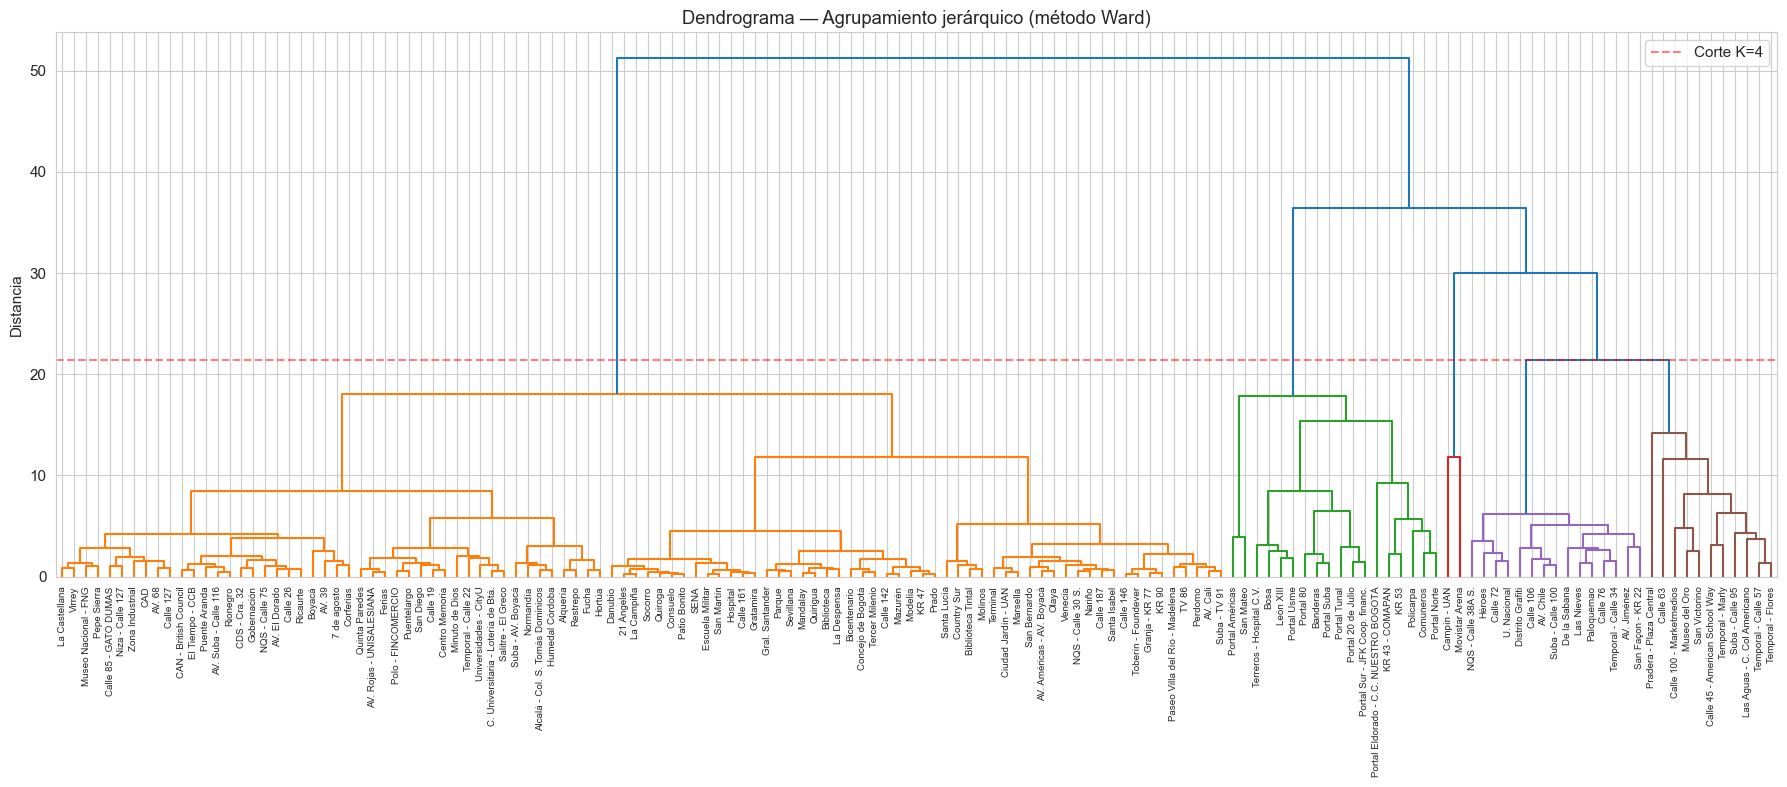

ARI entre K-Means y jerárquico (Ward): 0.924
  -> Alta concordancia, lo que valida la elección de K-Means.


In [13]:
# =============================================
# DENDROGRAMA (AGRUPAMIENTO JERÁRQUICO)
# =============================================

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z = linkage(X_cluster, method='ward')

fig, ax = plt.subplots(figsize=(18, 8))
dend = dendrogram(Z, labels=perfiles_pivot.index.values, leaf_rotation=90,
                  leaf_font_size=7, color_threshold=Z[-4, 2], ax=ax)  # corte en K=4
ax.set_title('Dendrograma — Agrupamiento jerárquico (método Ward)')
ax.set_ylabel('Distancia')
ax.axhline(y=Z[-4, 2], color='red', linestyle='--', alpha=0.5, label='Corte K=4')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_dendrograma.png'), dpi=150, bbox_inches='tight')
plt.show()

# ARI entre jerárquico y K-Means
hier_labels = fcluster(Z, t=4, criterion='maxclust')
ari_hier = adjusted_rand_score(perfiles_pivot['cluster'].values, hier_labels)
print(f"ARI entre K-Means y jerárquico (Ward): {ari_hier:.3f}")
if ari_hier > 0.7:
    print("  -> Alta concordancia, lo que valida la elección de K-Means.")

## 10. Pruebas estadísticas entre conglomerados

Prueba de Kruskal-Wallis para contrastar diferencias significativas de IPD entre los conglomerados identificados.

In [14]:
# =============================================
# KRUSKAL-WALLIS: DIFERENCIAS ENTRE CLUSTERS
# =============================================

from scipy import stats

ipd_by_cluster = [
    ipd_df[ipd_df['cluster'] == c]['ipd'].values
    for c in sorted(ipd_df['cluster'].dropna().unique())
]

h_stat, p_value = stats.kruskal(*ipd_by_cluster)
print(f"=== KRUSKAL-WALLIS: IPD entre conglomerados ===")
print(f"  H = {h_stat:.2f}, p = {p_value:.2e}")
print(f"  {'SIGNIFICATIVO' if p_value < 0.05 else 'No significativo'} (α=0.05)")

# Post-hoc: Mann-Whitney para cada par de clusters
from itertools import combinations
print(f"\n=== MANN-WHITNEY U — COMPARACIONES PAR A PAR ===")
clusters_unique = sorted(ipd_df['cluster'].dropna().unique())
for c1, c2 in combinations(clusters_unique, 2):
    data1 = ipd_df[ipd_df['cluster'] == c1]['ipd'].values
    data2 = ipd_df[ipd_df['cluster'] == c2]['ipd'].values
    u, p = stats.mannwhitneyu(data1, data2, alternative='two-sided')
    # Bonferroni correction
    n_tests = len(list(combinations(clusters_unique, 2)))
    sig = "***" if p < 0.001/n_tests else "**" if p < 0.01/n_tests else "*" if p < 0.05/n_tests else "ns"
    print(f"  Cluster {int(c1)} vs {int(c2)}: U={u:,.0f}, p={p:.2e} {sig}")

print(f"  (Corrección Bonferroni aplicada, {n_tests} comparaciones)")

=== KRUSKAL-WALLIS: IPD entre conglomerados ===
  H = 840358.05, p = 0.00e+00
  SIGNIFICATIVO (α=0.05)

=== MANN-WHITNEY U — COMPARACIONES PAR A PAR ===
  Cluster 0 vs 1: U=5,956,573,586,710, p=0.00e+00 ***
  Cluster 0 vs 2: U=102,259,344,818, p=0.00e+00 ***
  Cluster 0 vs 3: U=611,553,532,638, p=1.90e-181 ***
  Cluster 1 vs 2: U=213,222,047,354, p=0.00e+00 ***
  Cluster 1 vs 3: U=1,283,894,047,597, p=0.00e+00 ***
  Cluster 2 vs 3: U=42,263,635,942, p=0.00e+00 ***
  (Corrección Bonferroni aplicada, 6 comparaciones)


In [15]:
# === GUARDA EL PANEL CON CONGLOMERADO (costura hacia OE5) ===
import os; os.makedirs(DATA_INT, exist_ok=True); os.makedirs(OUT_TAB, exist_ok=True)
ipd_df.to_parquet(os.path.join(DATA_INT, 'panel_con_clusters.parquet'), index=False)
cluster_df.to_parquet(os.path.join(DATA_INT, 'cluster_df.parquet'), index=False)
cluster_df.to_csv(os.path.join(OUT_TAB, 'conglomerados_por_estacion.csv'), index=False)
print(f'Guardado panel_con_clusters ({len(ipd_df):,} filas) y cluster_df ({len(cluster_df)} estaciones)')


Guardado panel_con_clusters (7,957,878 filas) y cluster_df (144 estaciones)
